In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from scipy.signal import find_peaks, peak_widths,resample,correlate, correlation_lags,peak_prominences,resample,butter, lfilter, freqz,medfilt
from scipy.stats import pearsonr,wilcoxon,mannwhitneyu,kruskal
from matplotlib import rcParams
from scipy.stats import ttest_ind,ttest_rel,zscore
import scipy.io as spio

params = {
        "font.family" : "Arial",
        'pdf.fonttype' : 42,
        'axes.labelsize': 10,
        'axes.titlesize': 11,
        'axes.linewidth': 0.5,
        'xtick.labelsize':9,
        'xtick.major.width':0.5,
        'ytick.major.width':0.5,
        'ytick.labelsize':9,
        'axes.spines.top':False,
        'axes.spines.right':False
         }
rcParams['figure.figsize'] = 21.7,8.27
rcParams.update(params)
def format_ax(ax,xlim,ylim,xspace,yspace):
   

    ax.set_xticks(np.arange(xlim[0],xlim[1]+ xspace,xspace))
    ax.set_yticks(np.arange(ylim[0],ylim[1]+ yspace,yspace))

    ax.set(ylim=(ylim[0], ylim[1]))
    ax.set(xlim=(xlim[0], xlim[1]))


In [2]:
### Function to convert matlab struct to python dictionary, adapted from https://stackoverflow.com/questions/7008608/scipy-io-loadmat-nested-structures-i-e-dictionaries
def loadmat(filename):
    '''
    this function should be called instead of direct spio.loadmat
    as it cures the problem of not properly recovering python dictionaries
    from mat files. It calls the function check keys to cure all entries
    which are still mat-objects
    '''
    def _check_keys(d):
        '''
        checks if entries in dictionary are mat-objects. If yes
        todict is called to change them to nested dictionaries
        '''
        for key in d:
            if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
                d[key] = _todict(d[key])
        return d

    def _todict(matobj):
        '''
        A recursive function which constructs from matobjects nested dictionaries
        '''
        d = {}
        for strg in matobj._fieldnames:
            elem = matobj.__dict__[strg]
            if isinstance(elem, spio.matlab.mio5_params.mat_struct):
                d[strg] = _todict(elem)
            elif isinstance(elem, np.ndarray):
                d[strg] = _tolist(elem)
            else:
                d[strg] = elem
        return d

    def _tolist(ndarray):
        '''
        A recursive function which constructs lists from cellarrays
        (which are loaded as numpy ndarrays), recursing into the elements
        if they contain matobjects.
        '''
        elem_list = []
        for sub_elem in ndarray:
            if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):
                elem_list.append(_todict(sub_elem))
            elif isinstance(sub_elem, np.ndarray):
                elem_list.append(_tolist(sub_elem))
            else:
                elem_list.append(sub_elem)
        return elem_list
    data = spio.loadmat(filename, struct_as_record=False, squeeze_me=True)
    return _check_keys(data)

In [3]:
### Function to align trials to event onsets, adapted from https://www.tdt.com/docs/sdk/offline-data-analysis/offline-data-python/examples/LickBouts/#time-filter-around-lick-bout-epocs
def trial_align(event_on,time,values,fps = 20,pre = 2, post = 10):
    TRANGE = [-pre*np.floor(fps), post*np.floor(fps)]

    trial_snips = []
    array_ind = []
    pre_stim = []
    post_stim = []

    for on in event_on:
        
            # If the bout cannot include pre-time seconds before event, make zero
        if on < pre:
            pass

        else: 
            # find first time index after bout onset
            array_ind.append(np.where(time > on)[0][0])
            # find index corresponding to pre and post stim durations
            pre_stim.append(array_ind[-1] + TRANGE[0])
            post_stim.append(array_ind[-1] + TRANGE[1])
            trial_snips.append(values[int(pre_stim[-1]):int(post_stim[-1])])
    
    # If some snippets are less than max length, add nans to end of array

    max1 = np.max([np.size(x) for x in trial_snips])
    for i,x in enumerate(trial_snips):
        if np.size(x) < max1:
            trial_snips[i] = np.concatenate((trial_snips[i],np.full((max1-np.size(trial_snips[i])), np.nan)))
    
    mean_trial_snips = np.mean(trial_snips, axis=0)
    peri_time = np.linspace(1, len(mean_trial_snips), len(mean_trial_snips))/fps - pre
    return trial_snips,peri_time

In [4]:
### Path to data. RENAME THIS TO YOUR PATH
base_dir = "/Users/nithik/Library/CloudStorage/Box-Box/SAS-DLS-HudaLab/Nithik-SciAdv2026-alldata"

In [6]:
### Get data for FS7B (Left), S7C (Left), S7D (Left)
id_dates = { 
"004104" : ["20230911"],
"004103" : ["20230911"],
"004106" : ["20230912"],
"004107" : ["20230912"],
"004155" : ["20230912"],
"004105" : ["20230911"],
}

df_list = []

sess = 1
pre = 0.5
post = 2
for id,dates in id_dates.items():
    for date in dates:
        pupil_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_PupilProcessed.csv"
        matpath = rf"{base_dir}/{id}/{date}/EtOhBehavior_{id}_{date}_sess_{sess}.mat"
        mat_data = loadmat(matpath)["data"]
        laser_times = mat_data["response"]["laser_time"]
        data = mat_data["response"]["sessdata"]
        laser_durs = mat_data["response"]["trial_dur"]
        face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_FaceProcessed.csv"
        diffs = np.array(pd.read_csv(face_path)["Facial Movement"])

        trans = np.transpose(data)
        ard_times = trans[4]

        pupil_df = pd.read_csv(pupil_path)
        times = pupil_df["Time"].to_numpy()

        areas = pupil_df['Pupil Area'].to_numpy()
        wheel = trans[3]
        wheel[0] = 0
        wheel = np.interp(times,ard_times,wheel)
    
        wheel_snips,wheel_peri_times = trial_align(laser_times,times,wheel, pre = pre, post = post)
        pupil_snips,pupil_peri_times = trial_align(laser_times,times,areas,pre = pre, post = post)
        face_snips,face_peri_times = trial_align(laser_times,times,diffs, pre = pre, post = post)


        for j,trial in enumerate(wheel_snips):
            for i,time in enumerate(wheel_peri_times):
                new_dict = {"Time from Laser (s)" : time, "trial" : j, "value" : trial[i],"type" : "wheel", "ID" : id, "date" : date,"sess":sess}
                df_list.append(new_dict)
        
        for j,trial in enumerate(pupil_snips):
            pre_pupil = np.nanmean(trial[0:10])
            trial = trial - pre_pupil
            for i,time in enumerate(pupil_peri_times):
                new_dict = {"Time from Laser (s)" : time, "trial" : j, "value" : trial[i],"type" : "pupil", "ID" : id, "date" : date,"sess":sess}
                df_list.append(new_dict)

        
        for j,trial in enumerate(face_snips):
            pre_face = np.nanmean(trial[0:10])
            trial = trial - pre_face
            for i,time in enumerate(face_peri_times):
                new_dict = {"Time from Laser (s)" : time, "trial" : j, "value" : trial[i],"type" : "face", "ID" : id, "date" : date,"sess":sess}
                df_list.append(new_dict)


trial_df = pd.DataFrame.from_dict(df_list)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_10425/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_10425/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_10425/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_10425/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.mat

In [7]:
### Get data for FS7B (Right), S7C (Right), S7D (Right)
id_dates = { 
"004104" : ["20230911"],
"004103" : ["20230911"],
"004106" : ["20230912"],
"004107" : ["20230912"],
"004155" : ["20230912"],
"004105" : ["20230911"],
}

delta_list = []

sess = 1
pre = 0.5
post = 2
for id,dates in id_dates.items():
    for date in dates:
        pupil_path = rf"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_PupilProcessed.csv"
        matpath = rf"{base_dir}/{id}/{date}/EtOhBehavior_{id}_{date}_sess_{sess}.mat"
        mat_data = loadmat(matpath)["data"]
        laser_times = mat_data["response"]["laser_time"]
        data = mat_data["response"]["sessdata"]
        laser_durs = mat_data["response"]["trial_dur"]
        face_path = f"{base_dir}/{id}/{date}/{date}_{id}_sess_{sess}_FaceProcessed.csv"
        diffs = np.array(pd.read_csv(face_path)["Facial Movement"])

        trans = np.transpose(data)
        ard_times = trans[4]

        pupil_df = pd.read_csv(pupil_path)
        times = pupil_df["Time"].to_numpy()

        areas = pupil_df['Pupil Area'].to_numpy()
        wheel = trans[3]
        wheel[0] = 0
        wheel = np.interp(times,ard_times,wheel)
    
        wheel_snips,wheel_peri_times = trial_align(laser_times,times,wheel, pre = pre, post = post)
        pupil_snips,pupil_peri_times = trial_align(laser_times,times,areas,pre = pre, post = post)
        face_snips,face_peri_times = trial_align(laser_times,times,diffs, pre = pre, post = post)


        for j,trial in enumerate(wheel_snips):
            pre_laser = np.nanmean(trial[0:10])
            post_laser = np.nanmean(trial[10:50])
            delta = post_laser - pre_laser
            delta_dict = {"Delta" : delta,"ID" : id,'type':"wheel","Date":date,"trial":j}
            delta_list.append(delta_dict)

        
        for j,trial in enumerate(pupil_snips):
            pre_laser = np.nanmean(trial[0:10])
            post_laser = np.nanmean(trial[10:50])
            delta = post_laser - pre_laser
            delta_dict = {"Delta" : delta,"ID" : id,'type':"pupil","Date":date,"trial":j}
            delta_list.append(delta_dict)
        
        for j,trial in enumerate(face_snips):
            pre_laser = np.nanmean(trial[0:10])
            post_laser = np.nanmean(trial[10:50])
            delta = post_laser - pre_laser
            delta_dict = {"Delta" : delta,"ID" : id,'type':"face","Date":date,"trial":j}
            delta_list.append(delta_dict)


delta_df = pd.DataFrame.from_dict(delta_list)

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_10425/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(d[key], spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_10425/581762313.py:26: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_10425/581762313.py:42: DeprecationWarning: Please use `mat_struct` from the `scipy.io.matlab` namespace, the `scipy.io.matlab.mio5_params` namespace is deprecated.
  if isinstance(sub_elem, spio.matlab.mio5_params.mat_struct):
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_10425/581762313.py:15: DeprecationWarning: Please use `mat_struct` from the `scipy.io.mat

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_10425/1881236583.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = trial_df.groupby(["ID","Time from Laser (s)","type"]).mean().reset_index().query("type == 'wheel'"),x = "Time from Laser (s)", y = "value",errorbar = "se",linewidth = 1,color = "darkorange",legend = None)


Text(0, 0.5, 'Speed (AU)')

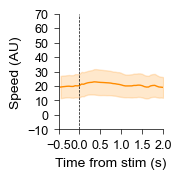

In [8]:
### Plot FigS7B (Left)
plt.figure(figsize = (1.35,1.5))
ax = sns.lineplot(data = trial_df.groupby(["ID","Time from Laser (s)","type"]).mean().reset_index().query("type == 'wheel'"),x = "Time from Laser (s)", y = "value",errorbar = "se",linewidth = 1,color = "darkorange",legend = None)
format_ax(ax,(-0.5,2),(-10,70),0.5,10)

ax.axvline(0,linestyle = "dashed", color = "black",linewidth = 0.5)

ax.set_xlabel("Time from stim (s)")
ax.set_ylabel('Speed (AU)')

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_10425/2842427568.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = delta_df.query("type == 'wheel'").groupby(["ID"]).mean().reset_index(), y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "darkorange")
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_10425/2842427568.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.stripplot(data = delta_df.query("type == 'wheel'").groupby(["ID"]).mean().reset_index(),y = "Delta",color = "black",alpha = 0.3,s = 4,jitter = 0.25)


Text(0, 0.5, '∆ Speed (AU)')

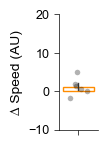

In [9]:
### Plot FigS7B (Right)

plt.figure(figsize = (0.5,1.5))
g = sns.barplot(data = delta_df.query("type == 'wheel'").groupby(["ID"]).mean().reset_index(), y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "darkorange")
sns.stripplot(data = delta_df.query("type == 'wheel'").groupby(["ID"]).mean().reset_index(),y = "Delta",color = "black",alpha = 0.3,s = 4,jitter = 0.25)
g.set_yticks(np.arange(-10,30,10))
g.set(ylim=(-10, 20))
g.set_ylabel("∆ Speed (AU)")

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_10425/508104613.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = trial_df.groupby(["ID","Time from Laser (s)","type"]).mean().reset_index().query("type == 'pupil'"),x = "Time from Laser (s)", y = "value",errorbar = "se",linewidth = 1,color = "dodgerblue",legend = None)


Text(0, 0.5, 'Pupil size (z-scr)')

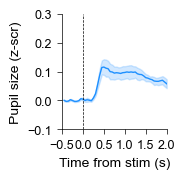

In [10]:
### Plot FigS7C (Left)

plt.figure(figsize = (1.35,1.5))
ax = sns.lineplot(data = trial_df.groupby(["ID","Time from Laser (s)","type"]).mean().reset_index().query("type == 'pupil'"),x = "Time from Laser (s)", y = "value",errorbar = "se",linewidth = 1,color = "dodgerblue",legend = None)
format_ax(ax,(-0.5,2),(-0.1,0.3),0.5,0.1)
ax.axvline(0,linestyle = "dashed", color = "black",linewidth = 0.5)
ax.set_xlabel("Time from stim (s)")
ax.set_ylabel("Pupil size (z-scr)")

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_10425/698518029.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = delta_df.query("type == 'pupil'").groupby(["ID"]).mean().reset_index(), y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "dodgerblue")
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_10425/698518029.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.stripplot(data = delta_df.query("type == 'pupil'").groupby(["ID"]).mean().reset_index(),y = "Delta",color = "black",alpha = 0.3,s = 4,jitter = 0.25)


Text(0, 0.5, '∆ Pupil size (z-scr)')

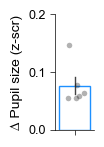

In [11]:
### Plot FigS7C (Right)

plt.figure(figsize = (0.5,1.5))
g = sns.barplot(data = delta_df.query("type == 'pupil'").groupby(["ID"]).mean().reset_index(), y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "dodgerblue")
sns.stripplot(data = delta_df.query("type == 'pupil'").groupby(["ID"]).mean().reset_index(),y = "Delta",color = "black",alpha = 0.3,s = 4,jitter = 0.25)
g.set_yticks(np.arange(0,0.3,0.1))
g.set(ylim=(0, 0.2))
g.set_ylabel("∆ Pupil size (z-scr)")

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_10425/2671004049.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ax = sns.lineplot(data = trial_df.groupby(["ID","Time from Laser (s)","type"]).mean().reset_index().query("type == 'face'"),x = "Time from Laser (s)", y = "value",errorbar = "se",linewidth = 1,color = "purple",legend = None)


Text(0, 0.5, 'Facial movement\n(z-scr)')

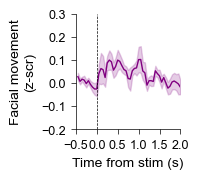

In [12]:
### Plot FigS7D (Left)

plt.figure(figsize = (1.35,1.5))
ax = sns.lineplot(data = trial_df.groupby(["ID","Time from Laser (s)","type"]).mean().reset_index().query("type == 'face'"),x = "Time from Laser (s)", y = "value",errorbar = "se",linewidth = 1,color = "purple",legend = None)
format_ax(ax,(-0.5,2),(-0.2,0.3),0.5,0.1)
ax.axvline(0,linestyle = "dashed", color = "black",linewidth = 0.5)
ax.set_xlabel("Time from stim (s)")
ax.set_ylabel("Facial movement\n(z-scr)")

/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_10425/772719355.py:4: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  g = sns.barplot(data = delta_df.query("type == 'face'").groupby(["ID"]).mean().reset_index(), y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "purple")
/var/folders/hs/_xmn26cn3qd9hcd5m8wjh6f80000gn/T/ipykernel_10425/772719355.py:5: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  sns.stripplot(data = delta_df.query("type == 'face'").groupby(["ID"]).mean().reset_index(),y = "Delta",color = "black",alpha = 0.3,s = 4,jitter = 0.25)


Text(0, 0.5, '∆ Facial movement (z-scr)')

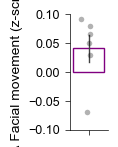

In [13]:
### Plot FigS7D (Right)

plt.figure(figsize = (0.5,1.5))
g = sns.barplot(data = delta_df.query("type == 'face'").groupby(["ID"]).mean().reset_index(), y = "Delta",errorbar = "se",fill = None,errwidth= 1,edgecolor = "purple")
sns.stripplot(data = delta_df.query("type == 'face'").groupby(["ID"]).mean().reset_index(),y = "Delta",color = "black",alpha = 0.3,s = 4,jitter = 0.25)
g.set_yticks(np.arange(-0.1,0.11,0.05))
g.set(ylim=(-0.1, 0.1))
g.set_ylabel("∆ Facial movement (z-scr)")